# Part 2 - Bayesian Sentiment Keywords

**Dataset:** `data/imdb_reviews_sample.csv` - a balanced 6,000-review sample drawn from the full 50k IMDb Movie Reviews dataset (2,992 positive / 3,008 negative), kept in the repo instead of the full 66 MB file since the keyword statistics only need a few thousand documents to stabilize.

**What's being computed:** for each keyword, `P(Positive | keyword)` only (not both directions - the assignment asks for one). Everything below is plain Python: dictionaries for word counts, no scikit-learn, no NLTK, no vectorizers.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
from bayes_sentiment import load_reviews, build_word_counts, bayes_breakdown

reviews = load_reviews('../data/imdb_reviews_sample.csv')
counts = build_word_counts(reviews)

print(f"positive reviews: {counts['pos_doc_count']}")
print(f"negative reviews: {counts['neg_doc_count']}")

positive reviews: 2992
negative reviews: 3008


## How the counts work

For each keyword, we count how many *documents* (not raw word occurrences) contain that word at least once, separately within the positive pile and the negative pile. Using document presence rather than raw frequency stops a single review that spams a word from skewing the estimate.

From those counts, for a keyword *w*:

- **Prior** - P(Positive) = (# positive reviews) / (# total reviews)
- **Likelihood** - P(w | Positive) = (# positive reviews containing w) / (# positive reviews)
- **Marginal** - P(w) = (# reviews containing w, either class) / (# total reviews) - the law of total probability applied over the two classes
- **Posterior** - P(Positive | w) = Likelihood x Prior / Marginal (Bayes' Theorem)

In [2]:
positive_keywords = ['excellent', 'wonderful', 'superb']
negative_keywords = ['terrible', 'awful', 'waste']

all_keywords = positive_keywords + negative_keywords
rows = [bayes_breakdown(w, counts) for w in all_keywords]

results = pd.DataFrame(rows)[[
    'keyword', 'docs_with_keyword_pos', 'docs_with_keyword_neg',
    'prior_P_positive', 'likelihood_P_keyword_given_positive',
    'marginal_P_keyword', 'posterior_P_positive_given_keyword',
]]
results.columns = [
    'Keyword', '# in Positive reviews', '# in Negative reviews',
    'Prior P(Positive)', 'Likelihood P(kw|Positive)',
    'Marginal P(kw)', 'Posterior P(Positive|kw)',
]
results

,Keyword,# in Positive reviews,# in Negative reviews,Prior P(Positive),Likelihood P(kw|Positive),Marginal P(kw),Posterior P(Positive|kw)
0,excellent,343,77,0.498667,0.114639,0.070000,0.816667
1,wonderful,253,59,0.498667,0.084559,0.052000,0.810897
2,superb,120,18,0.498667,0.040107,0.023000,0.869565
3,terrible,52,281,0.498667,0.017380,0.055500,0.156156
4,awful,34,304,0.498667,0.011364,0.056333,0.100592
5,waste,21,314,0.498667,0.007019,0.055833,0.062687


## Visualizing the posterior swing

Each bar is `P(Positive | keyword)`; the dashed line is the prior `P(Positive)`. Bars above the line are evidence for positive sentiment, bars below are evidence for negative.

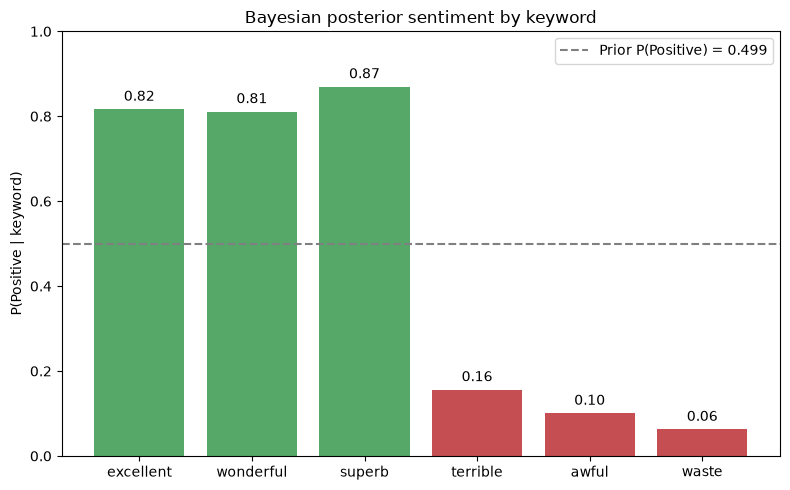

In [3]:
import matplotlib.pyplot as plt

posteriors = results['Posterior P(Positive|kw)'].values
keywords = results['Keyword'].values
prior = results['Prior P(Positive)'].iloc[0]
colors = ['#55A868' if kw in positive_keywords else '#C44E52' for kw in keywords]

plt.figure(figsize=(8, 5))
bars = plt.bar(keywords, posteriors, color=colors)
plt.axhline(prior, color='gray', ls='--', lw=1.5, label=f'Prior P(Positive) = {prior:.3f}')
plt.ylabel('P(Positive | keyword)')
plt.title('Bayesian posterior sentiment by keyword')
plt.ylim(0, 1)
for bar, val in zip(bars, posteriors):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f'{val:.2f}', ha='center')
plt.legend()
plt.tight_layout()
plt.show()


## Reading the table

The prior is identical for every row (2992/6000 = 0.4987) since it only depends on the overall class balance, not the keyword - that's expected and confirms the calculation isn't accidentally leaking keyword information into the prior.

What actually moves the posterior is the ratio between the likelihood and the marginal. Take **"excellent"**: it shows up in 343 of 2,992 positive reviews but only 77 of 3,008 negative reviews, so its likelihood (0.1147) comfortably outweighs its marginal frequency (0.0700), pulling the posterior up to ~0.82 - well above the 0.4987 prior. **"waste"** goes the other way: it's rare in positive reviews (21/2992 = 0.0070) but common in negative ones (314/3008), so its posterior P(Positive | waste) collapses to ~0.06, far below the prior. That gap between prior and posterior *is* the evidence the keyword provides - the bigger the swing, the more informative that single word is about sentiment on its own.